In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from py_code import add_variables
from py_code import get_variables
from py_code import initialize_df
import matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath,amssymb}"
plt.style.use('plots.mplstyle')
from matplotlib.patches import Patch, Rectangle

from sklearn.metrics import roc_auc_score

In [2]:
def smd(mean1, mean2, std1, std2):
    return abs(mean1-mean2)/(np.sqrt((std1**2+std2**2)/2))

In [3]:
ADC_MHz = 1000
pe_min = 13 #13 
pe_max = np.inf
df_singlemuons = initialize_df.get_df(path = f"dfs_traces/array/train/sm/100110TeV_030deg_200R200h_13FF_r0R300_shad1p15/Traces_DF_wpefrac.csv", base = "pe", ADC_MHz = ADC_MHz, pe_threshold = pe_min, pe_lim = pe_max)
df_bkg = initialize_df.get_df(path = f"dfs_traces/array/train/bkg/100110TeV_030deg_200R200h_13FF_r0R300_shad1p15/Traces_DF_wpefrac.csv", base = "pe", ADC_MHz = ADC_MHz, pe_threshold = pe_min, pe_lim = pe_max)
#df_singlemuons = initialize_df.get_df(path = f"dfs_traces/array/train/sm/100110TeV_030deg_180R170h_13FF_r0R300/Traces_DF_wpefrac.csv", base = "pe", ADC_MHz = ADC_MHz, pe_threshold = pe_min, pe_lim = pe_max)
#df_bkg = initialize_df.get_df(path = f"dfs_traces/array/train/bkg/100110TeV_030deg_180R170h_13FF_r0R300/Traces_DF_wpefrac.csv", base = "pe", ADC_MHz = ADC_MHz, pe_threshold = pe_min, pe_lim = pe_max)

In [4]:
df_singlemuons = add_variables.add_single_variable_to_df(df_singlemuons, get_variables.get_Asimmetry_6ch, min_time = 0 , max_time = 100,  ADC_MHz = ADC_MHz, ch0_present = False)
df_singlemuons = add_variables.add_single_variable_to_df(df_singlemuons, get_variables.get_total_pe)
df_singlemuons = add_variables.add_mult_variables_to_df(df_singlemuons, get_var = get_variables.get_ch_pe)

In [5]:
df_bkg = add_variables.add_single_variable_to_df(df_bkg, get_variables.get_Asimmetry_6ch, min_time = 0 , max_time = 100,  ADC_MHz = ADC_MHz, ch0_present = False)
df_bkg = add_variables.add_single_variable_to_df(df_bkg, get_variables.get_total_pe)
df_bkg = add_variables.add_mult_variables_to_df(df_bkg, get_var = get_variables.get_ch_pe)

In [6]:
df_mu   = df_singlemuons[df_singlemuons["IsThereMuon"]==1]
df_nomu = df_bkg[df_bkg["IsThereMuon"]==0]

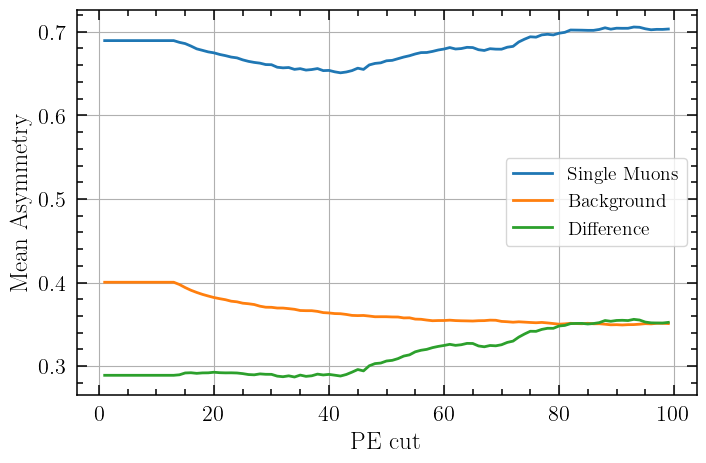

In [7]:
pe_cuts = range(1, 100)

mean_asym_smu = []
mean_asym_bkg = []
diff = []

for cut in pe_cuts:
    mask_smu = df_mu["total_pe"] >= cut
    mask_bkg = df_nomu["total_pe"] >= cut
    mean_asym_smu.append(df_mu[mask_smu]["a_6ch"].mean())
    mean_asym_bkg.append(df_nomu[mask_bkg]["a_6ch"].mean())
    diff.append(df_mu[mask_smu]["a_6ch"].mean() - df_nomu[mask_bkg]["a_6ch"].mean())

plt.figure(figsize=(8, 5))
plt.plot(pe_cuts, mean_asym_smu, label="Single Muons")
plt.plot(pe_cuts, mean_asym_bkg, label="Background")
plt.plot(pe_cuts, diff, label="Difference")


plt.xlabel("PE cut")
plt.ylabel("Mean Asymmetry")
plt.legend()
plt.grid(True)
plt.show()

Numero di Eventi di Fondo =  10959
Numero di Eventi di Muoni =  2473


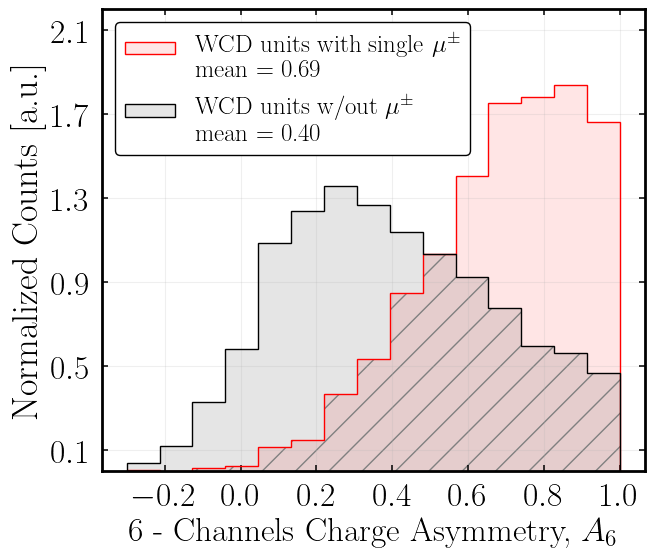

In [8]:
from matplotlib.legend_handler import HandlerBase
import matplotlib.transforms as mtransforms 

class OffsetHandler(HandlerBase):
    def __init__(self, x_offset=0, y_offset=0, **kwargs):
        self.x_offset = x_offset
        self.y_offset = y_offset
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        # Use the same type as the original handle
        patch = Rectangle(
            (0, 0), width, height,
            facecolor=orig_handle.get_facecolor(),
            edgecolor=orig_handle.get_edgecolor(),
            linewidth=orig_handle.get_linewidth()
        )
        # Apply offset
        offset_transform = trans + mtransforms.Affine2D().translate(self.x_offset, self.y_offset)
        patch.set_transform(offset_transform)
        return [patch]

plt.figure(figsize=(7, 6))

a6_mu, a6_nomu = df_mu["a_6ch"], df_nomu["a_6ch"]
print("Numero di Eventi di Fondo = ", len(a6_nomu))
print("Numero di Eventi di Muoni = ", len(a6_mu))

bins = 15
range_hist = (-0.3, 1.0)

counts_mu, bin_edges = np.histogram(a6_mu, bins=bins, range=range_hist, density=True)
counts_nomu, _ = np.histogram(a6_nomu, bins=bins, range=range_hist, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

overlap = np.minimum(counts_mu, counts_nomu)

mu_a_mean, mu_a_std = np.mean(a6_mu), np.std(a6_mu)
nomu_a_mean, nomu_a_std = np.mean(a6_nomu), np.std(a6_nomu)

smd_a = smd(mu_a_mean, nomu_a_mean, mu_a_std, nomu_a_std)
ovl_a = np.sum(overlap) * bin_width
tv_a  = 0.5 * np.sum(np.abs(counts_mu - counts_nomu)) * bin_width

y = np.r_[np.ones(len(a6_mu)), np.zeros(len(a6_nomu))]
scores = np.r_[a6_mu, a6_nomu]
mask = np.isfinite(scores)
auc_a = roc_auc_score(y[mask], scores[mask])

plt.hist(a6_mu, density=True, bins=bins, range=range_hist,
         histtype="stepfilled", color="red", alpha=0.1)
plt.hist(a6_mu, density=True, bins=bins, range=range_hist,
         histtype="step", color="red", lw=1)
plt.hist(a6_nomu, density=True, bins=bins, range=range_hist,
         histtype="stepfilled", color="black", alpha=0.1)
plt.hist(a6_nomu, density=True, bins=bins, range=range_hist,
         histtype="step", color="black", lw=1)

plt.bar(bin_centers, overlap, width=bin_width,
        color="none", edgecolor="gray", hatch="/", linewidth=0)

handles = [
    Rectangle((0,0),1,1, facecolor=(1,0,0,0.1), edgecolor=(1,0,0,1), linewidth=1),
    Rectangle((0,0),1,1, facecolor=(0,0,0,0.1), edgecolor=(0,0,0,1), linewidth=1)
]

labels = [
    r" WCD units with single $\mu^{\pm}$" + "\n" f"mean = {np.mean(a6_mu):.2f}",
    r" WCD units w/out $\mu^{\pm}$" + "\n" f"mean = {np.mean(a6_nomu):.2f}"
]

plt.xticks([-0.2,0,0.2,0.4,0.6,0.8,1])
plt.yticks([0.1, 0.5, 0.9, 1.3, 1.7, 2.1])
plt.ylim(0,2.2)
plt.tick_params(axis = "both", which = "major", labelsize = 24, length = 4)
plt.minorticks_off()
plt.xlabel(r"6 - Channels Charge Asymmetry, $A_{6}$", fontsize = 24)
plt.ylabel(r"Normalized Counts [a.u.]", fontsize = 26)
plt.grid(True, alpha = 0.2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

plt.legend(handles=handles, labels = labels, handler_map={Rectangle: OffsetHandler(x_offset = 0, y_offset=11)}, edgecolor="black", handleheight=0.4, facecolor="white", framealpha=1.0, fontsize=18)
#plt.savefig("/home/grieco/SWGO_Soft/ML_multiPMT/pictures/array/paper_1/a6_2R2h_shad1p15_triggertmin_metalwalls_2p0framethickness.pdf", dpi = 300, bbox_inches = "tight")
plt.show()


In [9]:
ADC_MHz = 1000
pe_min = 1
pe_max = np.inf
df_singlemuons_0pe = initialize_df.get_df(path = f"dfs_traces/array/train/sm/100110TeV_030deg_200R200h_13FF_r0R300_shad1p15/Traces_DF_wpefrac.csv", base = "pe", ADC_MHz = ADC_MHz, pe_threshold = pe_min, pe_lim = pe_max)
df_0pe_bkg = initialize_df.get_df(path = f"dfs_traces/array/train/bkg/100110TeV_030deg_200R200h_13FF_r0R300_shad1p15/Traces_DF_wpefrac.csv", base = "pe", ADC_MHz = ADC_MHz, pe_threshold = pe_min, pe_lim = pe_max)
df_0pe_bkg = add_variables.add_single_variable_to_df(df_0pe_bkg, get_variables.get_total_pe)
df_0pe_bkg = add_variables.add_mult_variables_to_df(df_0pe_bkg, get_var = get_variables.get_ch_pe)
df_singlemuons_0pe = add_variables.add_mult_variables_to_df(df_singlemuons_0pe, get_var = get_variables.get_ch_pe)

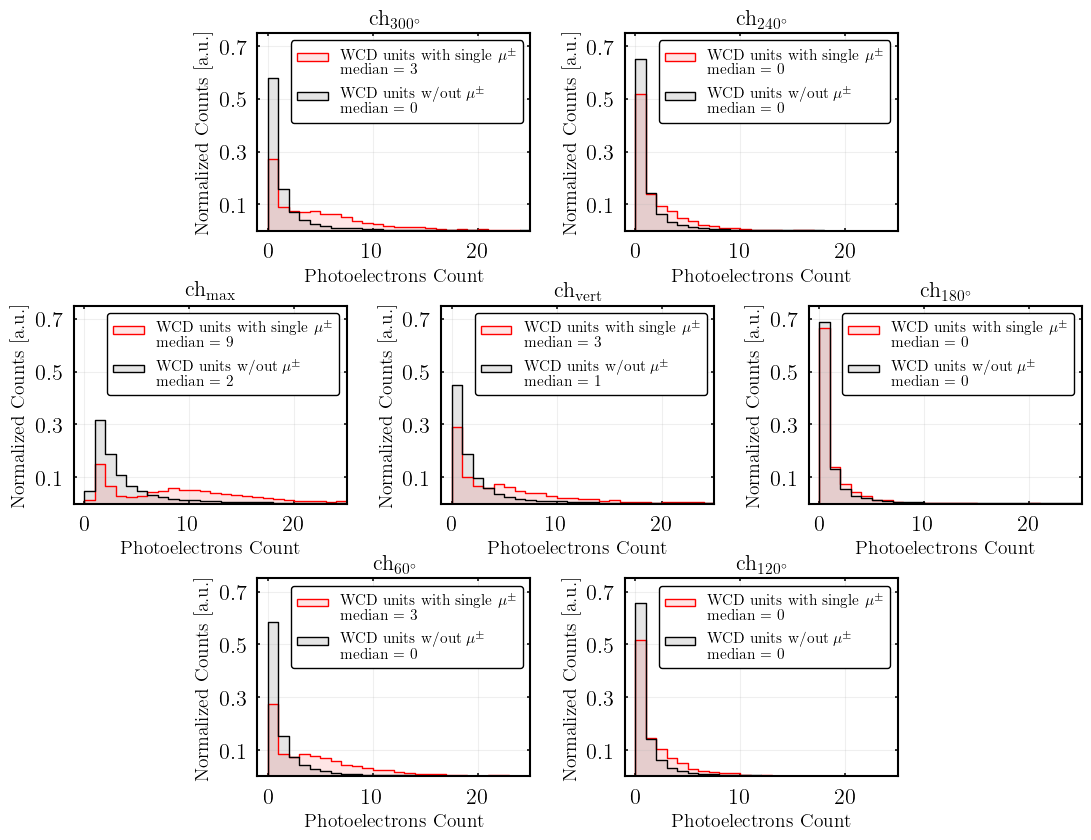

In [10]:
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
import matplotlib.transforms as mtransforms

class OffsetHandler(HandlerBase):
    def __init__(self, x_offset=0, y_offset=0, **kwargs):
        self.x_offset = x_offset
        self.y_offset = y_offset
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        patch = Rectangle(
            (0, 0), width, height,
            facecolor=orig_handle.get_facecolor(),
            edgecolor=orig_handle.get_edgecolor(),
            linewidth=orig_handle.get_linewidth()
        )
        offset_transform = trans + mtransforms.Affine2D().translate(self.x_offset, self.y_offset)
        patch.set_transform(offset_transform)
        return [patch]

ch_data_mu = {
    r"\mathrm{vert}": df_singlemuons_0pe["ch0_pe"],
    r"\mathrm{max}": df_singlemuons_0pe["chref_pe"],
    r"60^\circ": df_singlemuons_0pe["ch60_pe"],
    r"120^\circ": df_singlemuons_0pe["ch120_pe"],
    r"180^\circ": df_singlemuons_0pe["ch180_pe"],
    r"240^\circ": df_singlemuons_0pe["ch240_pe"],
    r"300^\circ": df_singlemuons_0pe["ch300_pe"],
}

ch_data_nomu = {
    r"\mathrm{vert}": df_0pe_bkg["ch0_pe"],
    r"\mathrm{max}": df_0pe_bkg["chref_pe"],
    r"60^\circ": df_0pe_bkg["ch60_pe"],
    r"120^\circ": df_0pe_bkg["ch120_pe"],
    r"180^\circ": df_0pe_bkg["ch180_pe"],
    r"240^\circ": df_0pe_bkg["ch240_pe"],
    r"300^\circ": df_0pe_bkg["ch300_pe"],
}

fig = plt.figure(figsize=(10.5, 9))
w, h = 0.26, 0.22
cx, cy = 0.50, 0.50
r = 0.35

pos = {
    "0":    [cx - w/2, cy - h/2, w, h], #0
    "180":  [cx + r - w/2, cy - h/2, w, h], #ref
    "240":   [cx + r*np.cos(np.deg2rad(60)) - w/2, cy + r*np.sin(np.deg2rad(60)) - h/2, w, h], #60
    "300":  [cx + r*np.cos(np.deg2rad(120)) - w/2, cy + r*np.sin(np.deg2rad(120)) - h/2, w, h], #120
    "ref":  [cx - r - w/2, cy - h/2, w, h], #180
    "60":  [cx + r*np.cos(np.deg2rad(240)) - w/2, cy + r*np.sin(np.deg2rad(240)) - h/2, w, h], #240
    "120":  [cx + r*np.cos(np.deg2rad(300)) - w/2, cy + r*np.sin(np.deg2rad(300)) - h/2, w, h], #300
}

axes_keys = ["0", "ref", "60", "120", "180", "240", "300"]
axes_list = [fig.add_axes(pos[k]) for k in axes_keys]

for a, label in zip(axes_list, ch_data_mu.keys()):
    pe_mu = ch_data_mu[label]
    pe_nomu = ch_data_nomu[label]

    counts_mu, bin_edges = np.histogram(pe_mu, bins=2000, range=(0, 2000), density=True)
    counts_nomu, _ = np.histogram(pe_nomu, bins=2000, range=(0, 2000), density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    plt_step_x_mu = np.r_[bin_edges[0], np.repeat(bin_edges, 2)[1:-1], bin_edges[-1]]
    plt_step_y_mu = np.r_[0, np.repeat(counts_mu, 2), 0]
    
    plt_step_x_nomu = np.r_[bin_edges[0], np.repeat(bin_edges, 2)[1:-1], bin_edges[-1]]
    plt_step_y_nomu = np.r_[0, np.repeat(counts_nomu, 2), 0]


    a.step(plt_step_x_mu, plt_step_y_mu, where="mid", color="red", lw=1)
    a.step(plt_step_x_nomu, plt_step_y_nomu, where="mid", color="black", lw=1)
    a.bar(bin_centers, counts_mu, width=bin_width, color="red", alpha=0.1, align="center")
    a.bar(bin_centers, counts_nomu, width=bin_width, color="black", alpha=0.1, align="center")

    a.set_xlim(-1, 25)
    a.set_ylim(0, 0.75)
    a.set_xlabel(r"Photoelectrons Count", fontsize=14)
    a.set_ylabel(r"Normalized Counts [a.u.]", fontsize=14)
    a.set_yticks([0.1, 0.3, 0.5, 0.7])
    
    for spine in a.spines.values():
        spine.set_linewidth(1.5)
        
    a.tick_params(axis="both", which="both", labelsize=16, length=2.5)
    a.minorticks_off()

    handles = [
        Rectangle((0,0),1,1, facecolor=(1,0,0,0.1), edgecolor=(1,0,0,1), linewidth=1),
        Rectangle((0,0),1,1, facecolor=(0,0,0,0.1), edgecolor=(0,0,0,1), linewidth=1)
    ]

    labels = [
        f"WCD units with single $\\mu^{{\\pm}}$\nmedian = {np.median(pe_mu):.0f}",
        f"WCD units w/out $\\mu^{{\\pm}}$\nmedian = {np.median(pe_nomu):.0f}"
    ]

    a.set_title(rf"$\mathrm{{ch}}_{{{label}}}$", fontsize=16)
    a.grid(True, alpha = 0.2)
    a.legend(handles, labels, handler_map={Rectangle: OffsetHandler(x_offset=0, y_offset=6.5)},
             frameon=True, facecolor="white", framealpha=1.0, fontsize=11, loc="upper right", handleheight=0.4, edgecolor="black")

plt.savefig("/home/grieco/SWGO_Soft/ML_multiPMT/pictures/array/paper_1/pe_per_channel_2mR2mh_shad1p15_triggertmin_metalwalls_spineframe1p5.pdf", dpi=300, bbox_inches="tight")
plt.show()

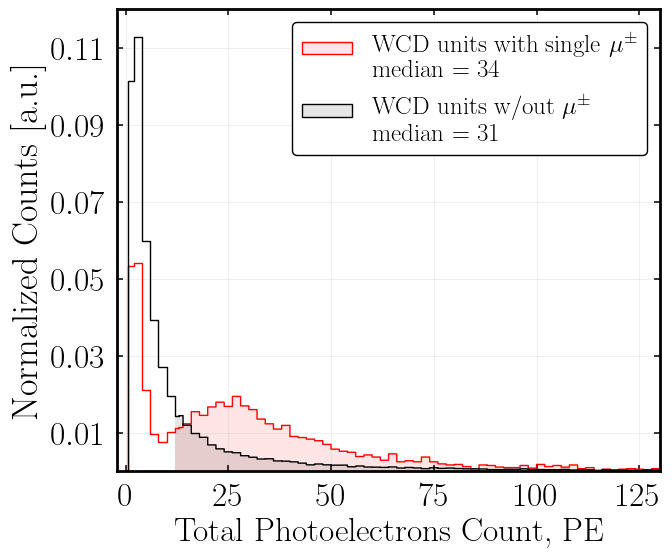

In [11]:
plt.figure(figsize=(7, 6))

pe_mu, pe_nomu = df_singlemuons_0pe["total_pe"], df_0pe_bkg["total_pe"]

bins = 1000
range_hist = (0, 2000)

counts_mu, bin_edges = np.histogram(pe_mu, bins=bins, range=range_hist, density=True)
counts_nomu, _ = np.histogram(pe_nomu, bins=bins, range=range_hist, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

mask_below = bin_centers <= 13
mask_above = bin_centers >= 13

x_step_mu = np.r_[bin_edges[0], bin_centers[mask_below]]
y_step_mu = np.r_[0, counts_mu[mask_below]]
plt.step(x_step_mu, y_step_mu, where="mid", color="red", lw=1)

x_step_nomu = np.r_[bin_edges[0], bin_centers[mask_below]]
y_step_nomu = np.r_[0, counts_nomu[mask_below]]
plt.step(x_step_nomu, y_step_nomu, where="mid", color="black", lw=1)

plt.bar(bin_centers[mask_above], counts_mu[mask_above],
        width=bin_width, color="red", alpha=0.1, align="center")
plt.bar(bin_centers[mask_above], counts_nomu[mask_above],
        width=bin_width, color="black", alpha=0.1, align="center")

plt.step(bin_centers[mask_above], counts_mu[mask_above], where="mid", color="red", lw=1)
plt.step(bin_centers[mask_above], counts_nomu[mask_above], where="mid", color="black", lw=1)

pe_mu_above = pe_mu[(pe_mu >= 13)]
pe_nomu_above = pe_nomu[(pe_nomu >= 13)]

handles = [
    Rectangle((0,0),1,1, facecolor=(1,0,0,0.1), edgecolor=(1,0,0,1), linewidth=1),
    Rectangle((0,0),1,1, facecolor=(0,0,0,0.1), edgecolor=(0,0,0,1), linewidth=1)
]

labels = [
    r" WCD units with single $\mu^{\pm}$" + "\n" f"median = {np.median(pe_mu_above):.0f}",
    r" WCD units w/out $\mu^{\pm}$" + "\n" f"median = {np.median(pe_nomu_above):.0f}"
]

plt.xticks([0, 25, 50, 75, 100, 125, 150])
plt.yticks([0.01, 0.03, 0.05, 0.07, 0.09, 0.11, 0.13])

plt.xlim(-2, 130)
plt.ylim(0, 0.12)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

plt.tick_params(axis="both", which="major", labelsize=24, length=4)
plt.minorticks_off()
plt.xlabel(r"Total Photoelectrons Count, \rm PE", fontsize=24)
plt.ylabel(r"Normalized Counts [a.u.]", fontsize=26)
plt.legend(handles=handles, labels=labels,
           handler_map={Rectangle: OffsetHandler(x_offset=0, y_offset=11)},
           handleheight=0.4, frameon=True, fontsize=18, loc="upper right", facecolor="white", framealpha=1.0, edgecolor="black")
plt.grid(True, alpha = 0.2)
plt.savefig("/home/grieco/SWGO_Soft/ML_multiPMT/pictures/array/paper_1/total_pe_2mR2mh_shad1p15_triggertmin_metalwalls_spineframe_2p0.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [12]:
pe_min = 13
df_test = initialize_df.get_df(path = f"dfs_traces/array/test/100110TeV_030deg_200R200h_13FF_r0R300_shad1p15/Traces_DF_wpefrac.csv", base = "pe", ADC_MHz = ADC_MHz, pe_threshold = pe_min, pe_lim = pe_max)
df_test_mu = df_test[df_test["IsThereMuon"] == 1]

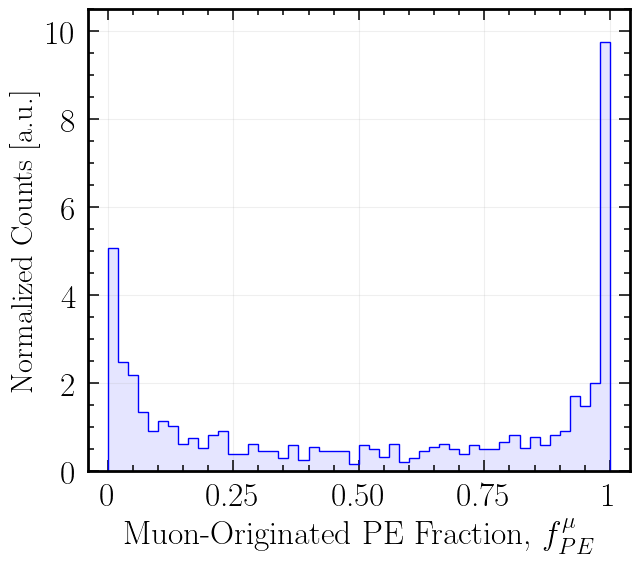

In [13]:
plt.figure(figsize=(7, 6))

frac_mu = df_test_mu["frac_mu"]

bins = 50
range_hist = (0, 1)

counts_frac_mu, bin_edges = np.histogram(frac_mu, bins=bins, range = range_hist, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

plt.hist(frac_mu, density = True, bins = bins, range = range_hist,
         histtype="stepfilled", color = "blue", alpha=0.1)
plt.hist(frac_mu, density = True, bins = bins, range = range_hist,
         histtype="step", color = "blue", lw=1)

handles = [
    Rectangle((0,0),1,1, facecolor=(0,0,1,0.1), edgecolor=(0,0,1,1), linewidth=1),
]

labels = [
    r" stations w/ $\mu^{\pm}$" + "\n" f"median = {np.median(frac_mu):.1f}",
]

ticks = [0, 0.25, 0.50, 0.75, 1]
tick_labels = ["0" if t == 0 else "1" if t == 1 else f"{t:.2f}" for t in ticks]

plt.xticks(ticks, tick_labels)

#plt.yticks([1, 3, 5, 7, 9, 11])
plt.yticks([0, 2, 4, 6, 8, 10])

plt.xlim(-0.04, 1.04)
plt.ylim(0, 10.5)

plt.tick_params(axis="both", which="major", labelsize=24, length=8)
#plt.minorticks_off()
plt.xlabel(r"Muon-Originated PE Fraction, $f^{\mu}_{PE}$", fontsize=24)
plt.ylabel(r"Normalized Counts [a.u.]", fontsize=22)
plt.grid(True, alpha = 0.2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

#plt.legend(handles=handles, labels=labels,
           #handler_map={Rectangle: OffsetHandler(x_offset=0, y_offset=20.5)},
           #handleheight=0.4, frameon=True, fontsize=15, loc = "upper center", facecolor="white", framealpha=1.0, edgecolor="black")
plt.savefig("/home/grieco/SWGO_Soft/ML_multiPMT/pictures/array/paper_1/frac_mu_13pe_2mR2mh_shad1p15_triggertmin_metalwalls_spineframe_2p0.pdf", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_3250957/2619960710.py:15: RuntimeWarning: divide by zero encountered in divide
  pdf = du / np.diff(icdf, append=icdf[-1])


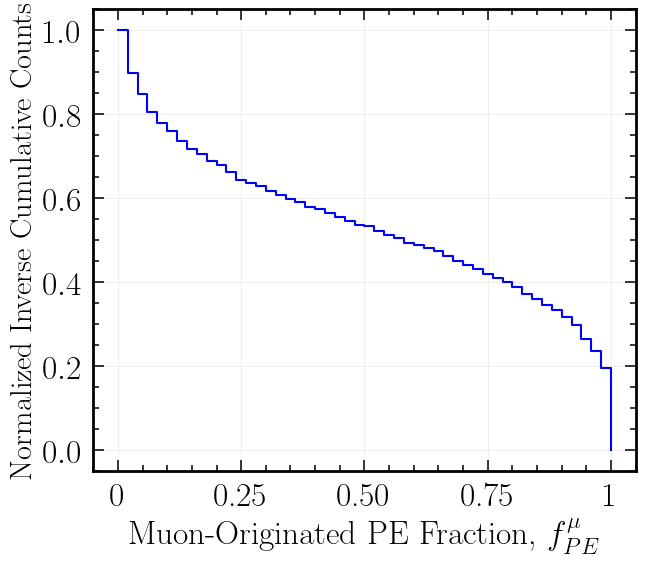

In [14]:
def binned_inv_cdf(data, bins):
    
    counts, bin_edges = np.histogram(data, bins=bins, range=(0, 1))
    survival = np.cumsum(counts[::-1])[::-1] / len(data)
    x = bin_edges[:-1]
    survival = np.r_[survival, 0]
    x = np.r_[x, bin_edges[-1]]   
    return x, survival

bins = 50
pr, icdf = binned_inv_cdf(frac_mu, bins=bins)
u = np.linspace(0, 1, len(icdf), endpoint=True)
du = u[1] - u[0]

pdf = du / np.diff(icdf, append=icdf[-1])

pdf = np.clip(pdf, 0, np.inf)

plt.figure(figsize=(7, 6))

plt.step(u, icdf, where="post", lw=1.5, color="blue", label=r"stations w/ $\mu^{\pm}$")

ticks = [0, 0.25, 0.50, 0.75, 1]
tick_labels = ["0" if t == 0 else "1" if t == 1 else f"{t:.2f}" for t in ticks]
plt.xticks(ticks, tick_labels)
#plt.yticks(ticks, tick_labels)

plt.tick_params(axis="both", which="major", labelsize=24, length=8)
#plt.minorticks_off()

plt.xlabel(r"Muon-Originated PE Fraction, $f^{\mu}_{PE}$", fontsize=24)
plt.ylabel("Normalized Inverse Cumulative Counts", fontsize = 22)
plt.xlim(-0.05, 1.05)
plt.grid(True, alpha = 0.2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

#plt.legend(frameon=True, fontsize=18, loc=(0.5,0.75), facecolor="white", framealpha=1, edgecolor = "black")

plt.savefig("/home/grieco/SWGO_Soft/ML_multiPMT/pictures/array/paper_1/inv_cum_frac_mu_13pe_2mR2mh_shad1p15_triggertmin_metalwalls_spineframe_2p0.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
ADC_MHz = 250
pe_min = 1
pe_max = np.inf
df_test_set_0pe = initialize_df.get_df(path = f"dfs_traces/array/test/100110TeV_030deg_200R200h_13FF_r0R300_shad1p15/Traces_DF_wpefrac.csv", base = "pe", ADC_MHz = ADC_MHz, pe_threshold = pe_min, pe_lim = pe_max)
df_test_set_0pe = add_variables.add_mult_variables_to_df(df_test_set_0pe, get_var = get_variables.get_ch_pe)

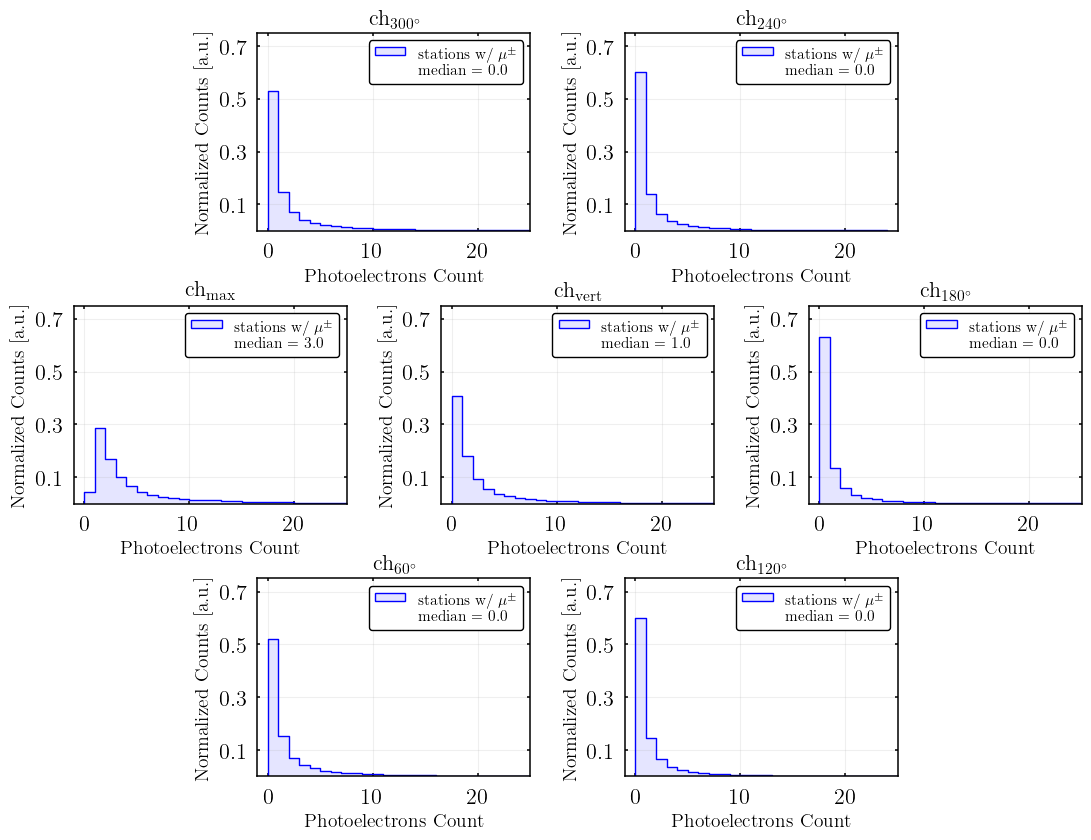

In [16]:
ch_data = {
    r"\mathrm{vert}": df_test_set_0pe["ch0_pe"],
    r"\mathrm{max}": df_test_set_0pe["chref_pe"],
    r"60^\circ": df_test_set_0pe["ch60_pe"],
    r"120^\circ": df_test_set_0pe["ch120_pe"],
    r"180^\circ": df_test_set_0pe["ch180_pe"],
    r"240^\circ": df_test_set_0pe["ch240_pe"],
    r"300^\circ": df_test_set_0pe["ch300_pe"],
}


fig = plt.figure(figsize=(10.5, 9))
w, h = 0.26, 0.22
cx, cy = 0.50, 0.50
r = 0.35

pos = {
    "0":    [cx - w/2, cy - h/2, w, h], #0
    "180":  [cx + r - w/2, cy - h/2, w, h], #ref
    "240":   [cx + r*np.cos(np.deg2rad(60)) - w/2, cy + r*np.sin(np.deg2rad(60)) - h/2, w, h], #60
    "300":  [cx + r*np.cos(np.deg2rad(120)) - w/2, cy + r*np.sin(np.deg2rad(120)) - h/2, w, h], #120
    "ref":  [cx - r - w/2, cy - h/2, w, h], #180
    "60":  [cx + r*np.cos(np.deg2rad(240)) - w/2, cy + r*np.sin(np.deg2rad(240)) - h/2, w, h], #240
    "120":  [cx + r*np.cos(np.deg2rad(300)) - w/2, cy + r*np.sin(np.deg2rad(300)) - h/2, w, h], #300
}

axes_keys = ["0", "ref", "60", "120", "180", "240", "300"]
axes_list = [fig.add_axes(pos[k]) for k in axes_keys]

for a, label in zip(axes_list, ch_data.keys()):
    
    pe_ = ch_data[label]

    counts_pe, bin_edges = np.histogram(pe_, bins=2000, range=(0, 2000), density=True)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    plt_step_x_pe = np.r_[bin_edges[0], np.repeat(bin_edges, 2)[1:-1], bin_edges[-1]]
    plt_step_y_pe = np.r_[0, np.repeat(counts_pe, 2), 0]



    a.step(plt_step_x_pe, plt_step_y_pe, where="mid", color="blue", lw=1)
    a.bar(bin_centers, counts_pe, width=bin_width, color="blue", alpha=0.1, align="center")


    a.set_xlim(-1, 25)
    a.set_ylim(0, 0.75)
    a.set_xlabel(r"Photoelectrons Count", fontsize=14)
    a.set_ylabel(r"Normalized Counts [a.u.]", fontsize=14)
    a.set_yticks([0.1, 0.3, 0.5, 0.7])
    a.tick_params(axis="both", which="both", labelsize=16, length=2.5)
    a.minorticks_off()

    handles = [
        Rectangle((0,0),1,1, facecolor=(0,0,1,0.1), edgecolor=(0,0,1,1), linewidth=1),
    ]

    labels = [
        f"stations w/ $\\mu^{{\\pm}}$\nmedian = {np.median(pe_):.1f}",
    ]

    a.set_title(rf"$\mathrm{{ch}}_{{{label}}}$", fontsize=16)
    a.grid(True, alpha = 0.2)
    a.legend(handles, labels, handler_map={Rectangle: OffsetHandler(x_offset=0, y_offset=12.5)},
             frameon=True, facecolor="white", framealpha=1.0, fontsize=11, loc="upper right", handleheight=0.4, edgecolor="black")

#plt.savefig("pictures/paper/all_particles_channels_pes_hexagon.pdf", dpi=300, bbox_inches="tight")
plt.show()